In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from fooof import FOOOF
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os

/var/folders/wy/8whx0tpj43sgygf2n0g0f5340000gn/T/ipykernel_1030/2963425951.py:4: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [3]:
adult_subs = ['011', '012', '013','014', '018','019', '021','022','025', '026', '030', '031']
child_subs = ['003', '002', '004', '006', '009', '010', '015', '016', '027', '028', '029']

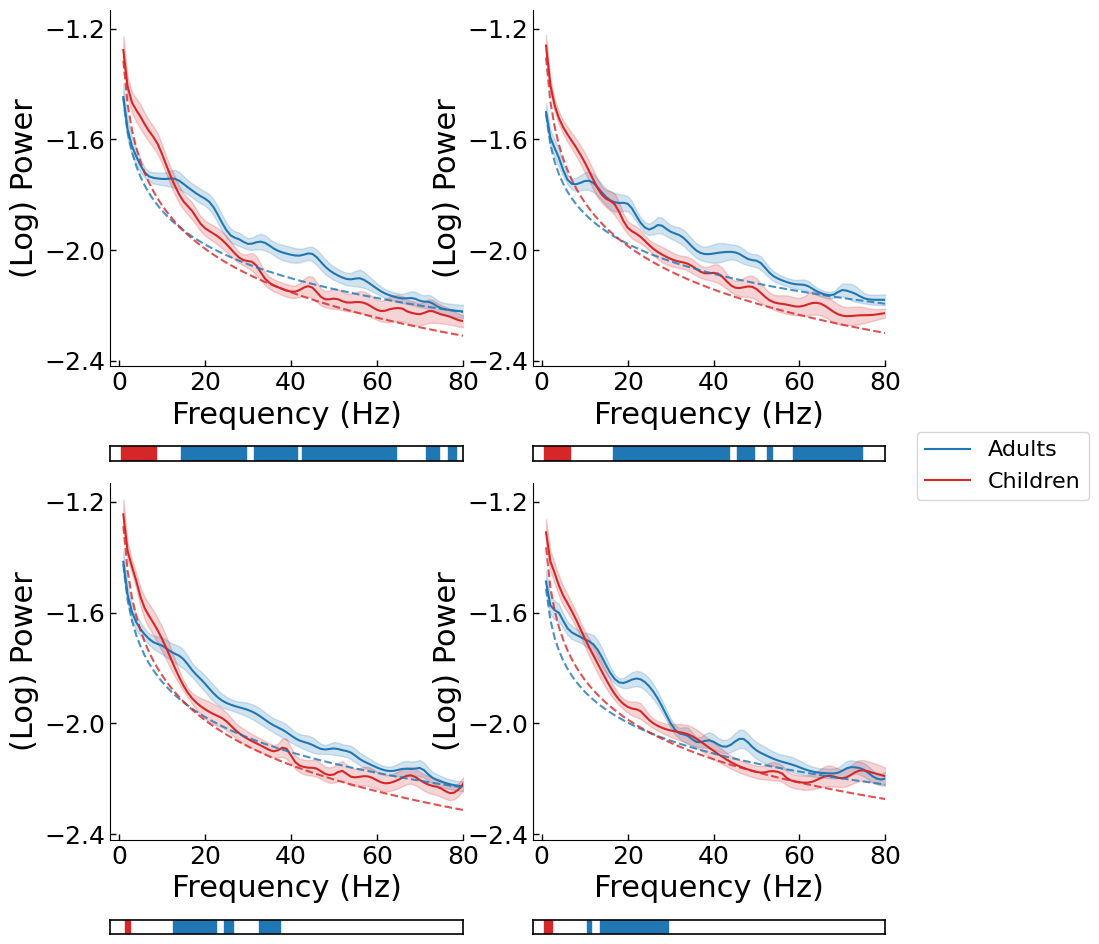

In [ ]:
# pre task power
# === Set up figure and axes
fig, axs = plt.subplots(2, 2, figsize=(10, 12), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.05)

freqs = np.linspace(1, 90, 90)
freq_range = [1, 90]
log_freqs = np.log10(freqs)

# === Define conditions and regions
conditions = ['g_el', 'g_ll']
brain_regions = ['motor', 'cerebellum']

# === Subplot mapping
subplot_map = {
    ('g_el', 'motor'): (0, 0),
    ('g_ll', 'motor'): (0, 1),
    ('g_el', 'cerebellum'): (1, 0),
    ('g_ll', 'cerebellum'): (1, 1),
}

# === Loop over each condition × brain region
for condition in conditions:
    for brain_region in brain_regions:

        # Load data
        path_child = f'../PSD_data/baseline_psds/{condition[2:]}_baseline_{brain_region}_normalized_psd_c.npy'
        path_adult = f'../PSD_data/baseline_psds/{condition[2:]}_baseline_{brain_region}_normalized_psd.npy'

        child_background_data = np.load(path_child)  # shape (90, n_childs)
        adult_background_data = np.load(path_adult)  # shape (90, n_adults)

        # Prep containers
        child_spectra = []
        adult_spectra = []
        child_backgrounds = []
        adult_backgrounds = []
        child_slopes = []
        adult_slopes = []

        # === Adults
        for i in range(len(adult_subs)):
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, adult_background_data[i], freq_range)
            adult_spectra.append(fm.fooofed_spectrum_)
            slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
            background = offset - slope * log_freqs
            adult_backgrounds.append(background)
            adult_slopes.append(slope)

        # === Children
        for i in range(len(child_subs)):
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, child_background_data[i], freq_range)
            child_spectra.append(fm.fooofed_spectrum_)
            slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
            background = offset - slope * log_freqs
            child_backgrounds.append(background)
            child_slopes.append(slope)

        # === Convert lists to arrays
        child_spectra = np.array(child_spectra)  # shape (n_childs, 90)
        adult_spectra = np.array(adult_spectra)

        # np.save(f'psd_data/foofed_background_{condition}_{brain_region}_child.npy', child_spectra)
        # np.save(f'psd_data/foofed_background_{condition}_{brain_region}_adult.npy', adult_spectra)

        # np.save(f'psd_data/slopes_rest_{condition}_{brain_region}_child.npy', np.array(child_slopes))
        # np.save(f'psd_data/slopes_rest_{condition}_{brain_region}_adult.npy', np.array(adult_slopes))

        child_backgrounds = np.array(child_backgrounds)
        adult_backgrounds = np.array(adult_backgrounds)

        # === Averages
        avg_child_spectrum = np.mean(child_spectra, axis=0)
        avg_adult_spectrum = np.mean(adult_spectra, axis=0)
        avg_child_background = np.mean(child_backgrounds, axis=0)
        avg_adult_background = np.mean(adult_backgrounds, axis=0)

        sem_child = np.std(child_spectra, axis=0, ddof=1) / np.sqrt(child_spectra.shape[0])
        sem_adult = np.std(adult_spectra, axis=0, ddof=1) / np.sqrt(adult_spectra.shape[0])

        # === Plotting
        row, col = subplot_map[(condition, brain_region)]
        ax = axs[row][col]

        # Create significance axis below main axis
        divider = make_axes_locatable(ax)
        sig_ax = divider.append_axes("bottom", size="4%", pad=0.8, sharex=ax)
        sig_ax.set_xlim(ax.get_xlim())
        sig_ax.set_ylim(-0.1, 0.1)
        sig_ax.set_xticks([])
        sig_ax.set_xticklabels([])
        sig_ax.set_yticks([])
        sig_ax.set_yticklabels([])
        sig_ax.tick_params(axis='both', which='both', bottom=False, top=False, labelbottom=False, left=False, right=False, labelleft=False)

        for side in ['left', 'right', 'bottom', 'top']:
            sig_ax.spines[side].set_visible(True)
            sig_ax.spines[side].set_color('black')
            sig_ax.spines[side].set_linewidth(1.2)

        # Try to load real p-values
        try:
            p_array = np.load(f'../PSD_data/pvals_{condition}_{brain_region}.npy')
            sig_mask = p_array < 0.05
            sig_freqs = freqs[sig_mask]
            for sf in sig_freqs:
                idx = np.argmin(np.abs(freqs - sf))
                color = 'tab:red' if avg_child_spectrum[idx] > avg_adult_spectrum[idx] else 'tab:blue'
                sig_ax.axvspan(sf - 0.5, sf + 0.5, color=color, alpha=1.0)
        except FileNotFoundError:
            print("NO FILE")

        # Plot average fooofed spectra
        ax.plot(freqs, avg_adult_spectrum, color='tab:blue', label='Adults')
        ax.plot(freqs, avg_child_spectrum, color='tab:red', label='Children')

        # Plot average aperiodic fits (dashed lines)
        ax.plot(freqs, avg_adult_background, color='tab:blue', linestyle='--', alpha=0.8)
        ax.plot(freqs, avg_child_background, color='tab:red', linestyle='--', alpha=0.8)

        # Plot SEM shading
        ax.fill_between(freqs, avg_adult_spectrum - sem_adult, avg_adult_spectrum + sem_adult,
                        color='tab:blue', alpha=0.2)
        ax.fill_between(freqs, avg_child_spectrum - sem_child, avg_child_spectrum + sem_child,
                        color='tab:red', alpha=0.2)

        # Style
        ax.set_xlim(left=-2)
        ax.set_xlabel('Frequency (Hz)', fontsize=22)
        ax.set_ylabel('(Log) Power', fontsize=22)
        ax.set_xticks([0, 20, 40, 60, 80])
        ax.set_xticklabels([0, 20, 40, 60, 80])
        ax.set_yticks([-2.4, -2.0, -1.6, -1.2])
        ax.tick_params(axis='both', labelsize=18)
        ax.tick_params(bottom=True, left=True, direction='in', length=4, width=1)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for spine in ax.spines.values():
            spine.set_color('black')
        ax.tick_params(labelleft=True)
        ax.tick_params(labelbottom=True)



# === Create a single figure legend
aperiodic_handle = mlines.Line2D([], [], color='gray', linestyle='--', label='Aperiodic signal')

handles, labels = [], []
for ax_row in axs:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

# Remove duplicates
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc='center left', bbox_to_anchor=(0.92, 0.5), fontsize=16)

# Save and Show
# plt.savefig('poster/big_labels_Baseline_Backgrounds_FOOOFed.png', dpi=300, bbox_inches='tight')
plt.show()


In [8]:
import numpy as np
from scipy.stats import ttest_ind
import os

# Setup
# conditions = ['g_el', 'g_ll']
conditions = ['el', 'll']
regions = ['motor', 'cerebellum']

# Store p-values
background_pvals = {}

for cond in conditions:
    for region in regions:
        # Load saved fooofed background spectra
        # child = np.load(f'../PSD_data/FOOFed PSD data/foofed_{cond}_{region}_child.npy')
        # adult = np.load(f'../PSD_data/FOOFed PSD data/foofed_{cond}_{region}_adult.npy')
        
        child = np.load(f'../PSD_data/baseline_psds/{cond}_baseline_{region}_normalized_psd_c.npy')
        adult = np.load(f'../PSD_data/baseline_psds/{cond}_baseline_{region}_normalized_psd.npy')

        # Perform t-test at each frequency
        t_stat, p = ttest_ind(adult, child, axis=0, equal_var=False)
        background_pvals[f'{cond}_{region}'] = p

        # Save p-values
        # np.save(f'../PSD_data/pvals_{cond}_{region}.npy', p)
        np.save(f'../PSD_data/baseline_psds/pvals_{cond}_{region}.npy', p)

freqs = np.linspace(1, 90, 90)

for key, p in background_pvals.items():
    sig_freqs = freqs[p < 0.05]
    print(f"{key}: {sig_freqs}")
    
# print(f"All p-values for {key}:")
# print(p)


el_motor: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 21. 23. 27. 28. 29. 31. 32. 33. 34.
 35. 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49.]
el_cerebellum: [ 1.  2.  3.  4.  5. 14. 15. 16. 17. 18. 26. 27. 28. 29. 33. 34. 35. 36.
 37. 41. 42. 47. 48. 49. 54.]
ll_motor: [ 1.  2.  3.  4.  5.  6.  7.  8. 19. 20. 21. 22. 25. 26. 27. 28. 29. 30.
 31. 32. 33. 34. 35. 36. 37. 38. 39. 40. 44. 45. 46. 47. 48. 49. 50. 51.
 54. 55. 57. 58. 81. 82. 83.]
ll_cerebellum: [ 1.  2.  3.  6.  7. 19. 20. 21. 22. 23. 24. 25. 26. 45. 46. 47. 48. 49.]


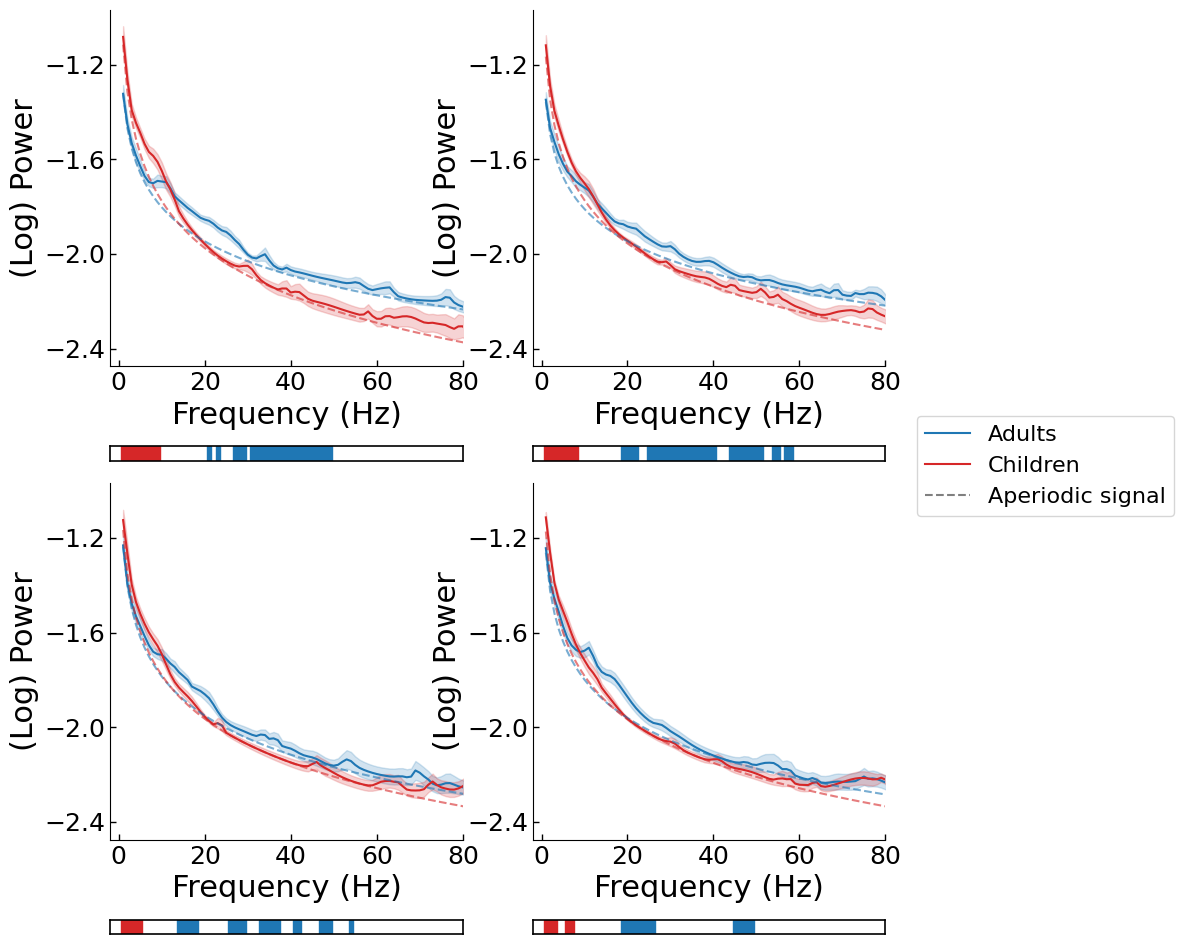

In [20]:
# Create the figure and axes grid *before* the loops
fig, axs = plt.subplots(2, 2, figsize=(10,12), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.05)
#fig.suptitle("Power Spectra \n in the Motor and Cerebellar Cortices", fontsize=24)

freqs = np.linspace(1,90,90)
freq_range = [1,90]

# Loop through each condition + region
for condition in ['g_el', 'g_ll']:
    for brain_region in ['motor', 'cerebellum']:        
        path_child = f'../PSD_data/{condition[2:]}_{brain_region}_normalized_psds_c.npy'
        path_adult = f'../PSD_data/{condition[2:]}_{brain_region}_normalized_psds.npy'

        child_data = np.load(path_child)
        adult_data = np.load(path_adult)

        # Prep containers
        child_spectra, adult_spectra = [], [] 
        adult_backgrounds, child_backgrounds = [], []
        adult_slopes, child_slopes = [], []

        log_freqs = np.log10(freqs)
        theta_mask = (freqs >= 4) & (freqs <= 8)
        alpha_mask = (freqs >= 8) & (freqs <= 12)

        # === Adults
        for i in range(len(adult_subs)): 
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, adult_data[i], freq_range)
            adult_spectra.append(fm.fooofed_spectrum_)
            slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
            background = offset - slope * log_freqs
            adult_backgrounds.append(background)
            adult_slopes.append(slope)

        # === Children
        for i in range(len(child_subs)): 
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, child_data[i], freq_range)
            child_spectra.append(fm.fooofed_spectrum_)
            slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
            background = offset - slope * log_freqs
            child_backgrounds.append(background)
            child_slopes.append(slope)


        #Save adult/children FOOFED spectra
        adult_spectra = np.array(adult_spectra)  # shape: [n_subjects, n_freqs]
        child_spectra = np.array(child_spectra)

        filename_adult = f'foofed_{condition}_{brain_region}_adult.npy'
        filename_child = f'foofed_{condition}_{brain_region}_child.npy'

        # np.save(filename_adult, adult_spectra)
        # np.save(filename_child, child_spectra)
        # np.save(f'background_{condition}_{brain_region}_adult.npy', np.array(adult_backgrounds))
        # np.save(f'background_{condition}_{brain_region}_child.npy', np.array(child_backgrounds))

        # np.save(f'psd_data/slopes_task_{condition}_{brain_region}_child.npy', np.array(child_slopes))
        # np.save(f'psd_data/slopes_task_{condition}_{brain_region}_adult.npy', np.array(adult_slopes))

        # === Averages
        avg_adult_spectrum = np.mean(adult_spectra, axis=0)
        avg_child_spectrum = np.mean(child_spectra, axis=0)
        avg_adult_background = np.mean(adult_backgrounds, axis=0)
        avg_child_background = np.mean(child_backgrounds, axis=0)

        # === Subplot mapping
        subplot_map = {
            ('g_el', 'motor'): (0, 0),
            ('g_ll', 'motor'): (0, 1),
            ('g_el', 'cerebellum'): (1, 0),
            ('g_ll', 'cerebellum'): (1, 1),
        }
        row, col = subplot_map[(condition, brain_region)]
        ax = axs[row][col]
        
        # === Create a connected significance axis below the main plot
        divider = make_axes_locatable(ax)
        sig_ax = divider.append_axes("bottom", size="4%", pad=0.8, sharex=ax)

        # Plot significant frequency squares
        p_array = np.load(f'../PSD_data/baseline_psds/pvals_{condition[2:]}_{brain_region}.npy')
        sig_mask = p_array < 0.05
        sig_freqs = freqs[sig_mask]
        for sf in sig_freqs:
            idx = np.argmin(np.abs(freqs - sf))
            color = 'tab:red' if avg_child_spectrum[idx] > avg_adult_spectrum[idx] else 'tab:blue'
            sig_ax.axvspan(sf - 0.5, sf + 0.5, color=color, alpha=1.0)

        # Format the significance axis (no ticks or labels)
        sig_ax.set_xlim(ax.get_xlim())
        sig_ax.set_ylim(-0.1, 0.1)
        sig_ax.set_xticks([])
        sig_ax.set_xticklabels([])
        sig_ax.set_yticks([])
        sig_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

        # Borders to match main plot
        for side in ['left', 'right', 'bottom', 'top']:
            sig_ax.spines[side].set_visible(True)
            sig_ax.spines[side].set_color('black')
            sig_ax.spines[side].set_linewidth(1.2)


        # === Plot
        ax.plot(freqs, avg_adult_spectrum, color='tab:blue', label='Adults')
        ax.plot(freqs, avg_child_spectrum, color='tab:red', label='Children')
        ax.plot(freqs, avg_adult_background, color='tab:blue', linestyle='--', alpha=0.6)
        ax.plot(freqs, avg_child_background, color='tab:red', linestyle='--', alpha=0.6)
        # ax.fill_between(freqs[theta_mask], avg_child_background[theta_mask], avg_child_spectrum[theta_mask],
        #                 color='tab:red', alpha=0.3)
        # ax.fill_between(freqs[alpha_mask], avg_adult_background[alpha_mask], avg_adult_spectrum[alpha_mask],
        #                 color='tab:blue', alpha=0.3)
        # ax.axvspan(4, 8, color='red', alpha=0.08)
        # ax.axvspan(8, 12, color='blue', alpha=0.08)
        
        # #Set Subplot Titles
        # ax.text(0.23, 0.92,
        # f"{brain_region.capitalize()} {'\n Early' if condition == 'g_el' else '\n Late'} Learning",
        # transform=ax.transAxes,
        # fontsize=16,
        # weight='bold',
        # verticalalignment='top',
        # bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

        # === Compute SEM from FOOOFed Spectra
        adult_spectra = np.array(adult_spectra)  # shape: [n_subjects, n_freqs]
        child_spectra = np.array(child_spectra)

        sem_adult = np.std(adult_spectra, axis=0, ddof=1) / np.sqrt(adult_spectra.shape[0])
        sem_child = np.std(child_spectra, axis=0, ddof=1) / np.sqrt(child_spectra.shape[0])

        # np.save(f'sem_{condition}_{brain_region}_adult.npy', sem_adult)
        # np.save(f'sem_{condition}_{brain_region}_child.npy', sem_child)

        # === Error Shading (SEM)
        ax.fill_between(freqs, avg_adult_spectrum - sem_adult, avg_adult_spectrum + sem_adult,
                        color='tab:blue', alpha=0.2)
        ax.fill_between(freqs, avg_child_spectrum - sem_child, avg_child_spectrum + sem_child,
                        color='tab:red', alpha=0.2)
        
        # # Load p-values
        # p_array = np.load(f'FOOFed PSD data/pvals_{condition}_{brain_region}.npy')
        # sig_mask = p_array < 0.05
        # sig_freqs = freqs[sig_mask]

        # # === Plot significance markers below the axis
        # sig_y = -2.55  # adjust slightly below your min y-tick (-2.4)
        # ax.scatter(sig_freqs, [sig_y]*len(sig_freqs), color='black', marker='s', s=8, alpha=0.7, label='p < 0.05')
        # ax.set_ylim([-2.6, -1])  # extend lower limit to fit sig markers
        
        
        ax.set_xlabel('Frequency (Hz)', fontsize=22)
        ax.set_xticks([0, 20, 40, 60, 80])
        ax.set_xticklabels([0, 20, 40, 60, 80])
        ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)

        ax.set_ylabel('(Log) Power', fontsize=22)
        ax.grid(False)
        ax.tick_params(axis='both', labelsize=18)  # or 14 if you want bigger
        #ax.tick_params(top=True, right=True, direction='in', length=4, width=1)
        ax.tick_params(bottom=True, left=True, direction='in', length=4, width=1)
        ax.tick_params(labelbottom=True)
        ax.tick_params(labelleft=True)
        ax.set_yticks([-2.4, -2.0, -1.6, -1.2])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for spine in ax.spines.values():
            spine.set_color('black')


# Custom aperiodic signal handle
aperiodic_handle = mlines.Line2D([], [], color='gray', linestyle='--', label='Aperiodic signal')

# Collect handles and labels from all subplots
handles, labels = [], []
for ax_row in axs:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

# Add the custom aperiodic signal
handles.append(aperiodic_handle)
labels.append('Aperiodic signal')

# Remove duplicates (optional)
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc='center left', bbox_to_anchor=(0.92, 0.5), fontsize=16)

#plt.tight_layout(rect=[0, 0, 1, 0.96])

# plt.savefig('poster/big_labels_Task_Periodic.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
np.load(f'../PSD_data/pvals_{condition}_{brain_region}.npy')

array([0.02489867, 0.00605974, 0.07107699, 0.20676922, 0.11365576,
       0.0697425 , 0.17150791, 0.51568328, 0.9192448 , 0.31208431,
       0.04650305, 0.0667084 , 0.13124394, 0.02650413, 0.01688445,
       0.00956615, 0.00233957, 0.00124497, 0.00174323, 0.00275568,
       0.00424618, 0.00728178, 0.0117363 , 0.01670287, 0.01897936,
       0.01458576, 0.01571462, 0.02471871, 0.04696771, 0.14026882,
       0.18197232, 0.10999823, 0.06933037, 0.07189784, 0.09602375,
       0.12912046, 0.16342078, 0.2061922 , 0.30979946, 0.56911049,
       0.78185757, 0.70166672, 0.48675955, 0.40667437, 0.41779643,
       0.40559991, 0.34694892, 0.34162699, 0.3821537 , 0.34308114,
       0.24802536, 0.17530839, 0.12514851, 0.13431539, 0.24236077,
       0.40536941, 0.37207961, 0.47911244, 0.38017589, 0.41468235,
       0.50438265, 0.54076461, 0.52640158, 0.73627173, 0.65640646,
       0.6532634 , 0.70531545, 0.75858884, 0.84543028, 0.97552896,
       0.90700917, 0.84383673, 0.80151059, 0.92261397, 0.89971